In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
import matplotlib.pyplot as plt
import os

I0000 00:00:1783846016.549809   38113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783846016.582256   38113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783846017.322903   38113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [3]:
dataset = os.path.join('datasets', 'AABA_2006-01-01_to_2018-01-01.csv')
df = pd.read_csv(dataset)
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   str    
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   str    
dtypes: float64(4), int64(1), str(2)
memory usage: 206.5 KB


In [5]:
data = df[['Open']]
data

,Open
0,39.69
1,41.22
2,40.93
3,42.88
4,43.10
...,...
3014,71.42
3015,70.94
3016,69.77
3017,70.12


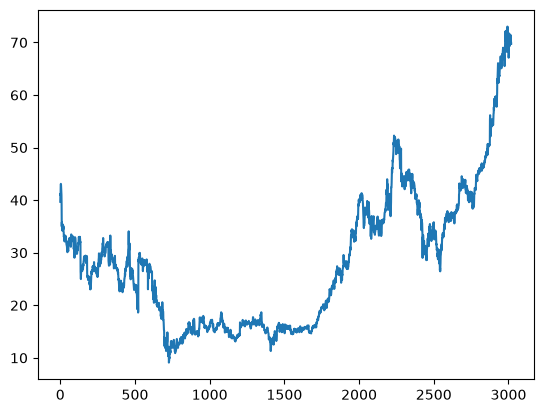

In [6]:
plt.plot(data['Open'])

In [7]:
X = data['Open'].values

In [8]:
X[:10]

array([39.69, 41.22, 40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  ,
       39.09])

In [9]:
X_train, X_test = X[:2500], X[2500:]

We can use GRU instead of LSTM in the code.

We can also use them in combination, for example, a LSTM layer and a GRU layer.

In [10]:
model = Sequential()
model.add(LSTM(units=128, activation='tanh', input_shape=((90, 1)), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=64, activation='tanh'))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

I0000 00:00:1783846018.415440   38113 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/docroch/Projects/learning-data-science/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='mean_absolute_error', optimizer='adam')

In [13]:
XT, yT = [], []
for i in range(len(X_train) - 90):
    d = i + 90
    XT.append(X_train[i:d,])
    yT.append(X_train[d])

In [14]:
Xt, yt = [], []
for i in range(len(X_test) - 90):
    d = i + 90
    Xt.append(X_test[i:d,])
    yt.append(X_test[d])

In [15]:
XT = np.array(XT)
Xt = np.array(Xt)

In [16]:
XT.shape

(2410, 90)

In [17]:
XT[2]

array([40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  , 39.09, 35.01,
       35.82, 34.44, 34.22, 34.55, 35.43, 34.94, 35.26, 35.06, 35.2 ,
       34.45, 35.01, 34.  , 33.9 , 33.01, 33.24, 33.01, 32.58, 32.21,
       32.14, 32.62, 33.3 , 32.88, 32.9 , 32.49, 33.01, 33.2 , 33.11,
       32.63, 32.21, 32.01, 31.7 , 31.53, 31.42, 31.31, 31.05, 30.4 ,
       30.72, 30.1 , 31.25, 30.77, 30.34, 30.38, 30.42, 30.33, 31.52,
       32.28, 31.84, 31.45, 32.44, 32.75, 32.45, 32.41, 31.69, 32.3 ,
       32.12, 32.85, 32.28, 32.45, 31.44, 31.14, 31.16, 31.17, 33.47,
       33.48, 33.36, 33.01, 32.99, 32.3 , 32.79, 32.88, 32.99, 32.2 ,
       32.4 , 32.4 , 32.63, 33.09, 32.68, 32.48, 31.96, 30.71, 30.85])

In [18]:
XT = np.reshape(XT, (XT.shape[0], XT.shape[1], 1))
Xt = np.reshape(Xt, (Xt.shape[0], Xt.shape[1], 1))

In [19]:
XT.shape

(2410, 90, 1)

In [20]:
XT[1]

array([[41.22],
       [40.93],
       [42.88],
       [43.1 ],
       [42.96],
       [42.19],
       [41.92],
       [41.  ],
       [39.09],
       [35.01],
       [35.82],
       [34.44],
       [34.22],
       [34.55],
       [35.43],
       [34.94],
       [35.26],
       [35.06],
       [35.2 ],
       [34.45],
       [35.01],
       [34.  ],
       [33.9 ],
       [33.01],
       [33.24],
       [33.01],
       [32.58],
       [32.21],
       [32.14],
       [32.62],
       [33.3 ],
       [32.88],
       [32.9 ],
       [32.49],
       [33.01],
       [33.2 ],
       [33.11],
       [32.63],
       [32.21],
       [32.01],
       [31.7 ],
       [31.53],
       [31.42],
       [31.31],
       [31.05],
       [30.4 ],
       [30.72],
       [30.1 ],
       [31.25],
       [30.77],
       [30.34],
       [30.38],
       [30.42],
       [30.33],
       [31.52],
       [32.28],
       [31.84],
       [31.45],
       [32.44],
       [32.75],
       [32.45],
       [32.41],
       [

In [21]:
yT = np.array(yT)
yt = np.array(yt)

In [22]:
history = model.fit(XT, yT, epochs=20, batch_size=20)

Epoch 1/20


I0000 00:00:1783846020.317137   38234 cuda_dnn.cc:461] Loaded cuDNN version 92400


121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 13.2429
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.5502
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.0916
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.0315
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6761
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.5078
Epoch 7/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.5083
Epoch 8/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3981
Epoch 9/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3269
Epoch 10/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.2968
Epoch 11/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3570
Epoch 12/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.2748
Epoch 13/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3064
Epoch 14/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.2888
Epoch 15/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.1785

In [23]:
model.evaluate(Xt, yt)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5746  


6.574576377868652

In [24]:
XTPredicted = model.predict(XT)
XtPredicted = model.predict(Xt)
XFinal = np.concatenate([XTPredicted, XtPredicted], axis=0)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


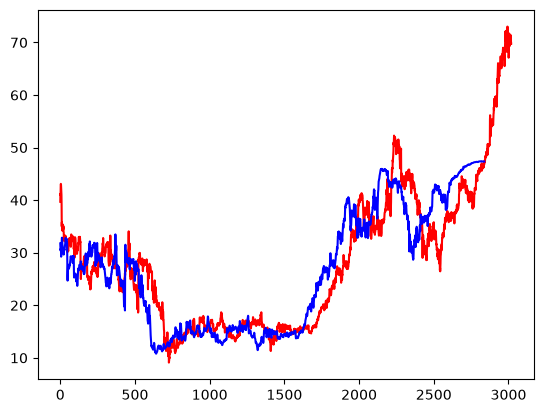

In [25]:
plt.plot(X, color='red')
plt.plot(XFinal, color='blue')